In [1]:
import pandas as pd
df_ambiente = pd.read_csv('/Users/pablocarcia/Library/CloudStorage/OneDrive-UNIR/TFM/DataSets/EDA/FSEC_Regional_Test_Ambient_data.csv')
df_sensores = pd.read_csv('/Users/pablocarcia/Library/CloudStorage/OneDrive-UNIR/TFM/DataSets/EDA/FSEC_Regional_Test_BaseLine_data.csv')

In [2]:
import pandas as pd
import numpy as np

def build_datetime(df):
    df = df.copy()

    df["DAY"] = df["DAY"].astype(str)
    df["YEAR"] = df["DAY"].str[:4].astype(int)
    df["DOY"] = df["DAY"].str[4:].astype(int)

    df["DATE"] = pd.to_datetime(
        df["YEAR"].astype(str) + df["DOY"].astype(str).str.zfill(3),
        format="%Y%j"
    )

    df["DATETIME"] = pd.to_datetime(
        df["DATE"].astype(str) + " " + df["HOUR"].astype(str)
    )

    return df.drop(columns=["YEAR", "DOY", "DATE"])

In [3]:
baseline = build_datetime(df_ambiente)
baseline = baseline.replace(32767, np.nan)
baseline = baseline.drop(columns=["Unnamed: 0"], errors="ignore")
baseline = baseline.drop_duplicates()

In [4]:
ambiental = build_datetime(df_sensores)
ambiental = ambiental.replace(32767, np.nan)
ambiental = ambiental.drop(columns=["Unnamed: 0"], errors="ignore")
ambiental = ambiental.drop_duplicates()

In [5]:
df = pd.merge(
    baseline,
    ambiental,
    on=["DAY", "HOUR", "DATETIME"],
    how="inner",
    suffixes=("_elec", "_amb")
)

df = df.sort_values("DATETIME")
df = df.set_index("DATETIME")

df = df[(df['DAY'] >= "2018001") & (df['DAY'] < "2024001")]

In [6]:
df_day = df[df["GHRADA"] > 100].copy()
display(df_day)

,DAY,HOUR,GHRADA,DIRRAA,DIFRAA,PMBARA,WSMEAN,WDIREA,WDIRST,WSMSST,...,REC2RE,LAMBTA,POAIR1,ICP1JT,ICP2JT,ICP3JT,ICP4JT,ICP5JT,ICP6JT,ICP7JT
DATETIME,,,,,,,,,,,,,,,,,,,,,
2018-01-01 08:29:00,2018001,08:29:00,102.1,0.9,108.3,1019.6,0.00,0.0,0.00,0.00,...,0.00,15.69,98.3,22.35,23.23,0.0,0.0,21.39,18.49,19.02
2018-01-01 08:30:00,2018001,08:30:00,109.2,0.9,115.9,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.71,105.7,22.41,23.27,0.0,0.0,21.46,18.55,19.08
2018-01-01 08:31:00,2018001,08:31:00,112.5,0.9,119.8,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.82,110.7,22.45,23.34,0.0,0.0,21.52,18.62,19.11
2018-01-01 08:32:00,2018001,08:32:00,111.3,0.9,119.2,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.92,111.6,22.49,23.45,0.0,0.0,21.57,18.67,19.14
2018-01-01 08:33:00,2018001,08:33:00,109.6,0.9,117.4,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.91,111.1,22.57,23.60,0.0,0.0,21.58,18.74,19.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 16:23:00,2023365,16:23:00,186.3,429.7,97.3,1022.4,1.52,241.0,19.08,0.63,...,0.02,137.44,354.8,26.88,27.37,0.0,0.0,25.55,22.87,23.74
2023-12-31 16:24:00,2023365,16:24:00,211.5,527.8,100.6,1022.4,0.86,234.0,16.97,0.72,...,0.02,138.17,380.6,26.90,27.36,0.0,0.0,25.53,22.84,23.72
2023-12-31 16:25:00,2023365,16:25:00,179.5,421.7,92.6,1022.4,1.67,232.1,21.97,0.45,...,0.02,138.67,348.6,26.93,27.35,0.0,0.0,25.48,22.83,23.69


In [7]:
missing_values_percentage = df.isnull().sum() / len(df) * 100
display(missing_values_percentage[missing_values_percentage > 0].sort_values(ascending=False))

REC1TE    47.960533
REC2TE    47.551727
DIRRAA    13.011372
MODT07     5.500057
MODT08     5.499962
            ...    
WSMSST     0.831051
WDIRST     0.831051
WDIREA     0.831051
WSMEAN     0.831051
PMBARA     0.831051
Length: 68, dtype: float64

In [8]:
df_day["hour"] = df_day.index.hour
df_day["minute"] = df_day.index.minute
df_day["dayofyear"] = df_day.index.dayofyear
df_day["month"] = df_day.index.month

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


""" # ============================================================
# 1. Preparación temporal
# ============================================================

df = pd.merge(
    baseline,
    ambiental,
    on=["DAY", "HOUR", "DATETIME"],
    how="inner",
    suffixes=("_elec", "_amb")
)

df = df.sort_values("DATETIME")
df = df.set_index("DATETIME")

# Usar 2018-2024 completo si existe en el dataset
df = df[
    (df["DAY"] >= "2018001") &
    (df["DAY"] < "2025001")
].copy() """


# ============================================================
# 2. Filtrado diurno
# ============================================================

df_day = df[df["GHRADA"] > 50].copy()

df_day["hour"] = df_day.index.hour
df_day["minute"] = df_day.index.minute
df_day["dayofyear"] = df_day.index.dayofyear
df_day["month"] = df_day.index.month


# ============================================================
# 3. Variables candidatas
# ============================================================

features_base = [
    "GHRADA", "DIRRAA", "DIFRAA",
    "TMPCAV", "RHPCTA", "WSMEAN",
    "hour", "minute", "dayofyear", "month"
]

features_extra = [
    "PMBARA", "WDIREA", "WDIRST", "WSMSST",
    "POAIR1", "LAMBTA",
    "ICP1JT", "ICP2JT", "ICP5JT", "ICP6JT", "ICP7JT"
]

# Variable objetivo del System 2
target = "S2WACA"

features_pred = [
    col for col in features_base + features_extra
    if col in df_day.columns
]


# ============================================================
# 4. Dataset de modelado
# ============================================================

data_pred = df_day[features_pred + [target]].copy()
data_pred = data_pred.replace([np.inf, -np.inf], np.nan)
data_pred = data_pred.dropna()

missing_by_year = (
    data_pred
    .assign(year=data_pred.index.year)
    .groupby("year")
    .apply(lambda x: x.drop(columns="year").isna().mean() * 100)
)

display(missing_by_year)



# ============================================================
# 5. Split temporal
# ============================================================

train = data_pred[data_pred.index < "2022-01-01"].copy()

val = data_pred[
    (data_pred.index >= "2022-01-01") &
    (data_pred.index < "2023-01-01")
].copy()

test = data_pred[
    (data_pred.index >= "2023-01-01") &
    (data_pred.index < "2024-01-01")
].copy()

print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)


# ============================================================
# 6. Limpieza del train
# ============================================================

train_clean = train.copy()

train_clean = train_clean[
    (train_clean["GHRADA"] > 50) &
    (train_clean[target] > 0) &
    (train_clean["RHPCTA"].between(0, 100)) &
    (train_clean["TMPCAV"].between(-10, 70)) &
    (train_clean["WSMEAN"] >= 0)
].copy()

# Eliminar casos físicamente incoherentes muy claros
train_clean = train_clean[
    ~(
        (train_clean["GHRADA"] > 500) &
        (train_clean[target] < 300)
    )
].copy()

# Recorte suave de extremos
lower_power_limit = train_clean[target].quantile(0.005)
upper_power_limit = train_clean[target].quantile(0.995)

train_clean = train_clean[
    train_clean[target].between(lower_power_limit, upper_power_limit)
].copy()

print("Tamaño train original:", train.shape)
print("Tamaño train limpio:", train_clean.shape)
print(
    "Porcentaje conservado:",
    round(len(train_clean) / len(train) * 100, 2),
    "%"
)


# ============================================================
# 7. Entrenamiento del modelo
# ============================================================

X_train = train_clean[features_pred]
y_train = train_clean[target]

X_val = val[features_pred]
y_val = val[target]

X_test = test[features_pred]
y_test = test[target]

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=28,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


# ============================================================
# 8. Evaluación
# ============================================================

def regression_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Resultados {name}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")
    print()


val = val.copy()
test = test.copy()

val["y_pred"] = rf_model.predict(X_val)
test["y_pred"] = rf_model.predict(X_test)

regression_metrics(val[target], val["y_pred"], "validación 2022")
regression_metrics(test[target], test["y_pred"], "test desde 2023")


# ============================================================
# 9. Residuales
# ============================================================

val["residual"] = val[target] - val["y_pred"]
test["residual"] = test[target] - test["y_pred"]

val["abs_residual"] = val["residual"].abs()
test["abs_residual"] = test["residual"].abs()

val["relative_error"] = (
    val["abs_residual"] /
    val["y_pred"].abs().clip(lower=100)
)

test["relative_error"] = (
    test["abs_residual"] /
    test["y_pred"].abs().clip(lower=100)
)


# ============================================================
# 10. Umbrales más sensibles
# ============================================================

# Antes usabas 0.995.
# Para detectar más anomalías bajamos a 0.990.
threshold_abs = val["abs_residual"].quantile(0.995)
threshold_rel = val["relative_error"].quantile(0.995)

val["underproduction_error"] = val["y_pred"] - val[target]
test["underproduction_error"] = test["y_pred"] - test[target]

threshold_under = val["underproduction_error"].quantile(0.995)

print("Umbral absoluto sensible:", threshold_abs)
print("Umbral relativo sensible:", threshold_rel)
print("Umbral subproducción sensible:", threshold_under)


# ============================================================
# 11. Detección de anomalías más sensible
# ============================================================

test["underproduction_ratio"] = (
    test["underproduction_error"] /
    test["y_pred"].abs().clip(lower=100)
)

# Anomalía por residuo absoluto
test["anomaly_abs_residual"] = (
    test["abs_residual"] > threshold_abs
).astype(int)

# Anomalía combinada por residuo absoluto y relativo
min_expected_power = 250

test["anomaly_rf_residual"] = (
    (test["y_pred"] > min_expected_power) &
    (test["abs_residual"] > threshold_abs) &
    (test["relative_error"] > threshold_rel)
).astype(int)

test["anomaly_rf_soft"] = (
    (test["y_pred"] > min_expected_power) &
    (
        (test["abs_residual"] > threshold_abs) |
        (test["relative_error"] > threshold_rel)
    )
).astype(int)

# Anomalía por residuo, pero solo cuando hay subproducción
test["anomaly_rf_under"] = (
    (test["anomaly_rf_residual"] == 1) &
    (test["residual"] < 0)
).astype(int)

# Subproducción refinada, más sensible
test["anomaly_underproduction_refined"] = (
    (test["underproduction_error"] > threshold_under) &
    (test["underproduction_ratio"] > 0.15) &
    (test["y_pred"] > 250)
).astype(int)

# Potencia baja con sol, más sensible
test["anomaly_zero_power_with_sun"] = (
    (test["GHRADA"] > 150) &
    (test["y_pred"] > 250) &
    (test[target] < 150)
).astype(int)

# Anomalía soft general
test["anomaly_rf_soft"] = (
    (test["abs_residual"] > threshold_abs) |
    (test["relative_error"] > threshold_rel)
).astype(int)

# Anomalía final sensible
test["anomaly_final"] = (
    (test["anomaly_rf_under"] == 1) |
    (test["anomaly_underproduction_refined"] == 1) |
    (test["anomaly_zero_power_with_sun"] == 1)
).astype(int)


# ============================================================
# 12. Resumen de anomalías
# ============================================================

print("\nAnomalías por residuo absoluto:")
print(test["anomaly_abs_residual"].value_counts(normalize=True) * 100)

print("\nAnomalías combinadas:")
print(test["anomaly_rf_residual"].value_counts(normalize=True) * 100)

print("\nAnomalías por residuo negativo:")
print(test["anomaly_rf_under"].value_counts(normalize=True) * 100)

print("\nAnomalías de subproducción refinada:")
print(test["anomaly_underproduction_refined"].value_counts(normalize=True) * 100)

print("\nAnomalías físicas: potencia baja con sol:")
print(test["anomaly_zero_power_with_sun"].value_counts(normalize=True) * 100)

print("\nAnomalías soft:")
print(test["anomaly_rf_soft"].value_counts(normalize=True) * 100)

print("\nAnomalía final sensible:")
print(test["anomaly_final"].value_counts(normalize=True) * 100)

/var/folders/z4/0f39p73148q9qzf1bl7k2vsr0000gn/T/ipykernel_34947/499981685.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.drop(columns="year").isna().mean() * 100)


,GHRADA,DIRRAA,DIFRAA,TMPCAV,RHPCTA,WSMEAN,hour,minute,dayofyear,month,...,WDIRST,WSMSST,POAIR1,LAMBTA,ICP1JT,ICP2JT,ICP5JT,ICP6JT,ICP7JT,S2WACA
year,,,,,,,,,,,,,,,,,,,,,
2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Train: (760850, 22)
Val: (97994, 22)
Test: (210507, 22)
Tamaño train original: (760850, 22)
Tamaño train limpio: (612460, 22)
Porcentaje conservado: 80.5 %
Resultados validación 2022
MAE : 57.26
RMSE: 76.61
R2  : 0.9891

Resultados test desde 2023
MAE : 88.55
RMSE: 118.14
R2  : 0.9721

Umbral absoluto sensible: 224.47044000172545
Umbral relativo sensible: 0.5899239008527449
Umbral subproducción sensible: 217.58478357275578

Anomalías por residuo absoluto:
anomaly_abs_residual
0    96.838585
1     3.161415
Name: proportion, dtype: float64

Anomalías combinadas:
anomaly_rf_residual
0    99.826134
1     0.173866
Name: proportion, dtype: float64

Anomalías por residuo negativo:
anomaly_rf_under
0    99.881239
1     0.118761
Name: proportion, dtype: float64

Anomalías de subproducción refinada:
anomaly_underproduction_refined
0    99.462251
1     0.537749
Name: proportion, dtype: float64

Anomalías físicas: potencia baja con sol:
anomaly_zero_power_with_sun
0    99.884564
1     0.115436
Nam

,n_anomalias,porcentaje
anomaly_abs_residual,6655.0,3.1614
anomaly_rf_residual,366.0,0.1739
anomaly_rf_under,250.0,0.1188
anomaly_underproduction_refined,1132.0,0.5377
anomaly_zero_power_with_sun,243.0,0.1154
anomaly_rf_soft,7812.0,3.7110
anomaly_final,1158.0,0.5501


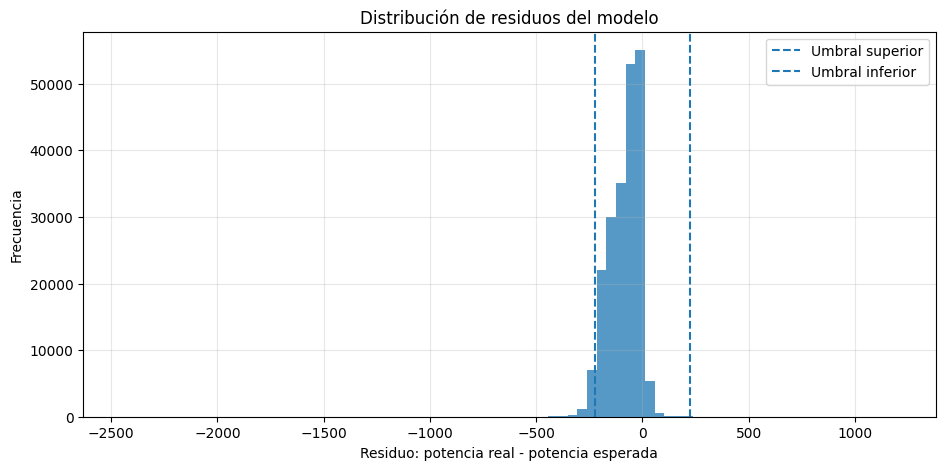

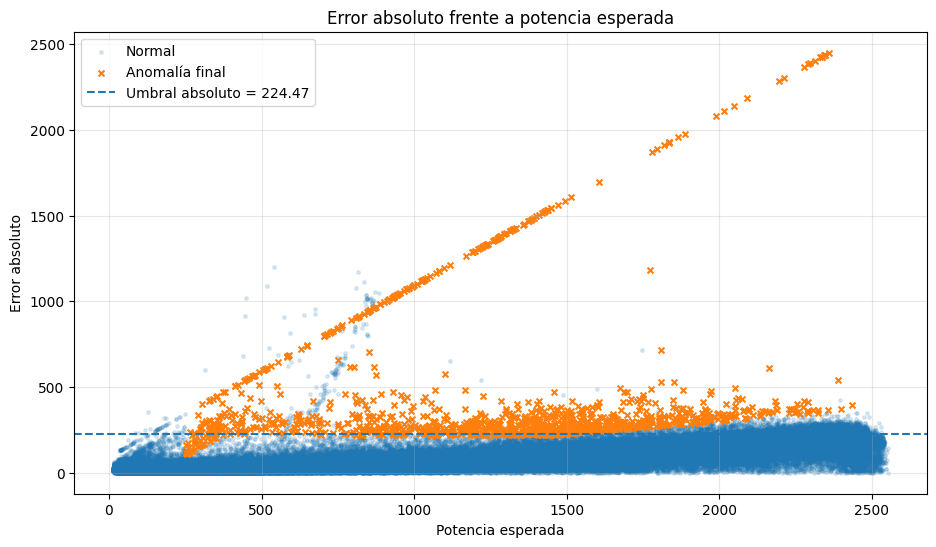

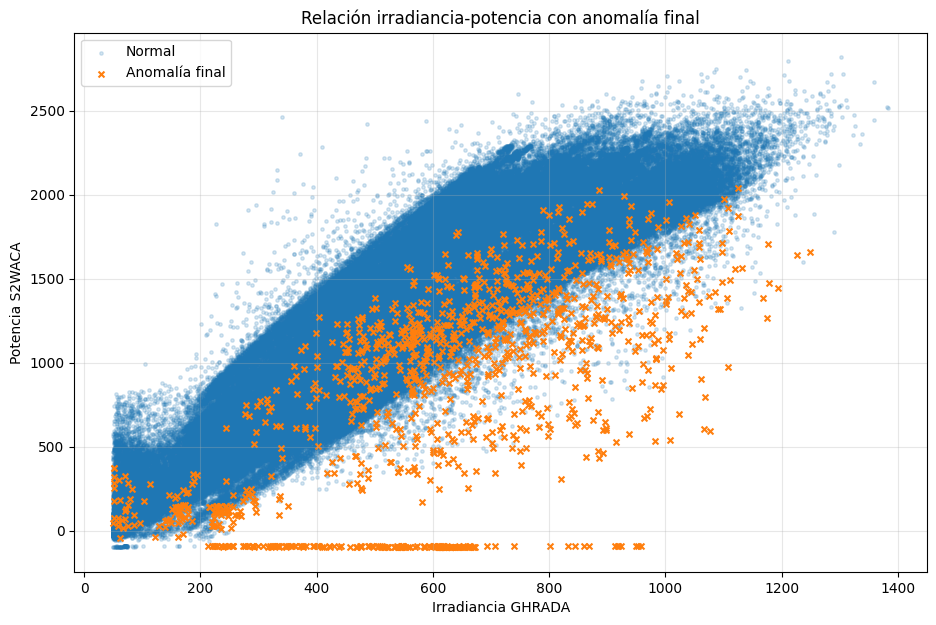

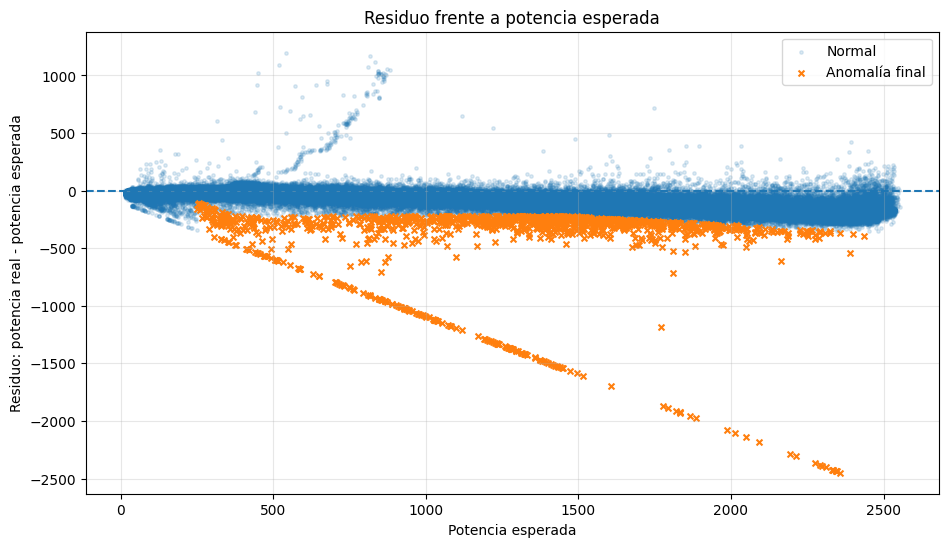

POAIR1       0.422373
GHRADA       0.263704
DIRRAA       0.154406
hour         0.047488
RHPCTA       0.045017
DIFRAA       0.021962
dayofyear    0.008277
LAMBTA       0.008104
month        0.005817
ICP1JT       0.005072
ICP5JT       0.003414
PMBARA       0.002838
ICP7JT       0.002662
ICP6JT       0.002260
ICP2JT       0.002205
TMPCAV       0.001800
minute       0.000938
WDIREA       0.000513
WSMEAN       0.000469
WSMSST       0.000360
WDIRST       0.000319
dtype: float64

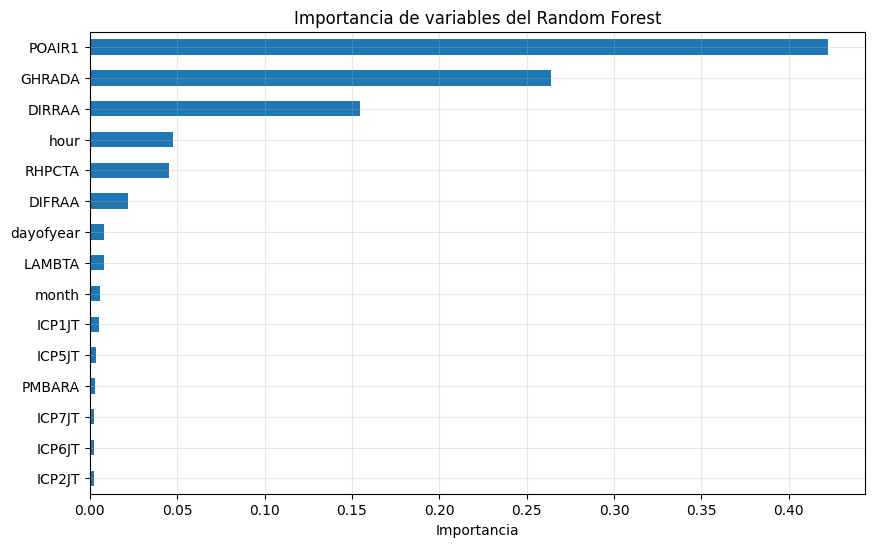

Número total de anomalías finales: 1158
Porcentaje de anomalías finales: 0.5501 %


,GHRADA,DIRRAA,DIFRAA,TMPCAV,RHPCTA,WSMEAN,hour,minute,dayofyear,month,...,relative_error,underproduction_error,underproduction_ratio,anomaly_abs_residual,anomaly_rf_residual,anomaly_rf_soft,anomaly_rf_under,anomaly_underproduction_refined,anomaly_zero_power_with_sun,anomaly_final
DATETIME,,,,,,,,,,,,,,,,,,,,,
2023-01-04 12:21:00,633.5,11.1,320.0,27.68,63.23,3.75,12,21,4,1,...,0.176266,279.890786,0.176266,1,0,1,0,1,0,1
2023-01-04 12:22:00,453.6,13.4,309.0,27.79,62.56,3.84,12,22,4,1,...,0.183338,218.524524,0.183338,0,0,0,0,1,0,1
2023-01-08 09:41:00,436.0,830.2,111.5,20.65,67.25,2.35,9,41,8,1,...,0.190324,289.220879,0.190324,1,0,1,0,1,0,1
2023-01-08 09:42:00,339.5,594.4,112.8,20.63,67.63,1.80,9,42,8,1,...,0.368324,288.454904,0.368324,1,0,1,0,1,0,1
2023-01-08 10:25:00,491.7,641.7,195.1,22.45,60.17,1.54,10,25,8,1,...,0.176957,259.358943,0.176957,1,0,1,0,1,0,1


,valor
MAE,88.552812
RMSE,118.139643
R2,0.972087
% anomalías residuo absoluto,3.161415
% anomalías soft,3.711040
% anomalías fuertes,0.173866


In [10]:
# ============================================================
# 13. Tabla resumen
# ============================================================

def resumen_tipos_anomalia(test):
    cols = [
        "anomaly_abs_residual",
        "anomaly_rf_residual",
        "anomaly_rf_under",
        "anomaly_underproduction_refined",
        "anomaly_zero_power_with_sun",
        "anomaly_rf_soft",
        "anomaly_final"
    ]

    resumen = {}

    for col in cols:
        resumen[col] = {
            "n_anomalias": int(test[col].sum()),
            "porcentaje": round(test[col].mean() * 100, 4)
        }

    return pd.DataFrame(resumen).T


display(resumen_tipos_anomalia(test))


# ============================================================
# 14. Gráficas
# ============================================================

def plot_residual_distribution(test, threshold_abs):
    plt.figure(figsize=(11, 5))

    plt.hist(
        test["residual"],
        bins=80,
        alpha=0.75
    )

    plt.axvline(
        threshold_abs,
        linestyle="--",
        label="Umbral superior"
    )

    plt.axvline(
        -threshold_abs,
        linestyle="--",
        label="Umbral inferior"
    )

    plt.title("Distribución de residuos del modelo")
    plt.xlabel("Residuo: potencia real - potencia esperada")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_abs_error_vs_prediction(test, threshold_abs):
    normal = test[test["anomaly_final"] == 0]
    anomaly = test[test["anomaly_final"] == 1]

    plt.figure(figsize=(11, 6))

    plt.scatter(
        normal["y_pred"],
        normal["abs_residual"],
        s=6,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anomaly["y_pred"],
        anomaly["abs_residual"],
        s=18,
        marker="x",
        label="Anomalía final"
    )

    plt.axhline(
        threshold_abs,
        linestyle="--",
        label=f"Umbral absoluto = {threshold_abs:.2f}"
    )

    plt.title("Error absoluto frente a potencia esperada")
    plt.xlabel("Potencia esperada")
    plt.ylabel("Error absoluto")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_irradiance_power_final(test, target="S2WACA"):
    normal = test[test["anomaly_final"] == 0]
    anomaly = test[test["anomaly_final"] == 1]

    plt.figure(figsize=(11, 7))

    plt.scatter(
        normal["GHRADA"],
        normal[target],
        s=6,
        alpha=0.18,
        label="Normal"
    )

    plt.scatter(
        anomaly["GHRADA"],
        anomaly[target],
        s=18,
        marker="x",
        label="Anomalía final"
    )

    plt.xlabel("Irradiancia GHRADA")
    plt.ylabel(f"Potencia {target}")
    plt.title("Relación irradiancia-potencia con anomalía final")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_residual_vs_prediction(test):
    normal = test[test["anomaly_final"] == 0]
    anomaly = test[test["anomaly_final"] == 1]

    plt.figure(figsize=(11, 6))

    plt.scatter(
        normal["y_pred"],
        normal["residual"],
        s=6,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anomaly["y_pred"],
        anomaly["residual"],
        s=18,
        marker="x",
        label="Anomalía final"
    )

    plt.axhline(0, linestyle="--")

    plt.title("Residuo frente a potencia esperada")
    plt.xlabel("Potencia esperada")
    plt.ylabel("Residuo: potencia real - potencia esperada")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def create_model_summary(
    y_true,
    y_pred,
    df_result
):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    summary = pd.DataFrame({
        "valor": [
            mae,
            rmse,
            r2,
            df_result["anomaly_abs_residual"].mean() * 100,
            df_result["anomaly_rf_soft"].mean() * 100,
            df_result["anomaly_rf_residual"].mean() * 100
        ]
    }, index=[
        "MAE",
        "RMSE",
        "R2",
        "% anomalías residuo absoluto",
        "% anomalías soft",
        "% anomalías fuertes"
    ])

    return summary

def plot_random_forest_feature_importance(features_pred, rf_model):
    importances = pd.Series(
        rf_model.feature_importances_,
        index=features_pred
    ).sort_values(ascending=False)

    display(importances)

    plt.figure(figsize=(10, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Importancia de variables del Random Forest")
    plt.xlabel("Importancia")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_residual_distribution(test, threshold_abs)
plot_abs_error_vs_prediction(test, threshold_abs)
plot_irradiance_power_final(test, target=target)
plot_residual_vs_prediction(test)
plot_random_forest_feature_importance(features_pred, rf_model)


# ============================================================
# 15. Export opcional de anomalías
# ============================================================

anomalias = test[test["anomaly_final"] == 1].copy()

print("Número total de anomalías finales:", len(anomalias))
print("Porcentaje de anomalías finales:", round(len(anomalias) / len(test) * 100, 4), "%")

display(anomalias.head())

summary_model = create_model_summary(
    y_true=test["S2WACA"],
    y_pred=test["y_pred"],
    df_result=test
)

display(summary_model)

In [11]:
""" def plot_irradiance_power_scatter(test, target="S2WACA", anomalia_col="anomaly_final"):
    normal = test[test[anomalia_col] == 0]
    anomaly = test[test[anomalia_col] == 1]

    plt.figure(figsize=(11, 7))

    plt.scatter(
        normal["GHRADA"],
        normal[target],
        s=6,
        alpha=0.18,
        label="Normal"
    )

    plt.scatter(
        anomaly["GHRADA"],
        anomaly[target],
        s=18,
        marker="x",
        label="Anomalía final"
    )

    plt.xlabel("Irradiancia GHRADA")
    plt.ylabel(f"Potencia {target}")
    plt.title("Relación irradiancia-potencia con anomalía final")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_residual_distribution(test, threshold_abs):
    plt.figure(figsize=(11, 5))

    plt.hist(
        test["residual"],
        bins=80,
        alpha=0.75
    )

    plt.axvline(
        threshold_abs,
        linestyle="--",
        label="Umbral superior"
    )

    plt.axvline(
        -threshold_abs,
        linestyle="--",
        label="Umbral inferior"
    )

    plt.title("Distribución de residuos del modelo")
    plt.xlabel("Residuo: potencia real - potencia esperada")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_abs_error_vs_prediction(test, threshold_abs):
    normal = test[test["anomaly_final"] == 0]
    anomaly = test[test["anomaly_final"] == 1]

    plt.figure(figsize=(11, 6))

    plt.scatter(
        normal["y_pred"],
        normal["abs_residual"],
        s=6,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anomaly["y_pred"],
        anomaly["abs_residual"],
        s=18,
        marker="x",
        label="Anomalía final"
    )

    plt.axhline(
        threshold_abs,
        linestyle="--",
        label=f"Umbral absoluto = {threshold_abs:.2f}"
    )

    plt.title("Error absoluto frente a potencia esperada")
    plt.xlabel("Potencia esperada")
    plt.ylabel("Error absoluto")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_residual_vs_prediction(test):
    normal = test[test["anomaly_final"] == 0]
    anomaly = test[test["anomaly_final"] == 1]

    plt.figure(figsize=(11, 6))

    plt.scatter(
        normal["y_pred"],
        normal["residual"],
        s=6,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anomaly["y_pred"],
        anomaly["residual"],
        s=18,
        marker="x",
        label="Anomalía final"
    )

    plt.axhline(0, linestyle="--")

    plt.title("Residuo frente a potencia esperada")
    plt.xlabel("Potencia esperada")
    plt.ylabel("Residuo: potencia real - potencia esperada")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
 """

' def plot_irradiance_power_scatter(test, target="S2WACA", anomalia_col="anomaly_final"):\n    normal = test[test[anomalia_col] == 0]\n    anomaly = test[test[anomalia_col] == 1]\n\n    plt.figure(figsize=(11, 7))\n\n    plt.scatter(\n        normal["GHRADA"],\n        normal[target],\n        s=6,\n        alpha=0.18,\n        label="Normal"\n    )\n\n    plt.scatter(\n        anomaly["GHRADA"],\n        anomaly[target],\n        s=18,\n        marker="x",\n        label="Anomalía final"\n    )\n\n    plt.xlabel("Irradiancia GHRADA")\n    plt.ylabel(f"Potencia {target}")\n    plt.title("Relación irradiancia-potencia con anomalía final")\n    plt.legend()\n    plt.grid(True, alpha=0.3)\n    plt.show()\n\ndef plot_residual_distribution(test, threshold_abs):\n    plt.figure(figsize=(11, 5))\n\n    plt.hist(\n        test["residual"],\n        bins=80,\n        alpha=0.75\n    )\n\n    plt.axvline(\n        threshold_abs,\n        linestyle="--",\n        label="Umbral superior"\n    )\n\

In [12]:
""" plot_residual_distribution(test,threshold_abs=threshold_abs)
plot_abs_error_vs_prediction(test,threshold_abs=threshold_abs)
plot_irradiance_power_scatter(test,anomalia_col="anomaly_rf_soft")
plot_irradiance_power_scatter(test,anomalia_col="anomaly_rf_residual")
plot_irradiance_power_scatter(test,anomalia_col="anomaly_abs_residual")
plot_residual_vs_prediction(test) """

' plot_residual_distribution(test,threshold_abs=threshold_abs)\nplot_abs_error_vs_prediction(test,threshold_abs=threshold_abs)\nplot_irradiance_power_scatter(test,anomalia_col="anomaly_rf_soft")\nplot_irradiance_power_scatter(test,anomalia_col="anomaly_rf_residual")\nplot_irradiance_power_scatter(test,anomalia_col="anomaly_abs_residual")\nplot_residual_vs_prediction(test) '